# Feature Engineering

**Goal:** 

**Key outputs from EDA that we will use:**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
df = pd.read_excel("../../data_processed/quarterly_data.xlsx")
df = df.drop(columns=["ROE"]) 
df_fe = df.copy()

df_fe.head()

,date,CPI,usd_uah,policy_rate,gdp_growth,NPL,CAR,ROA,loans,capital
0,2017Q1,13.966667,27.049589,14.000000,0.028,55.106022,13.72,1.64,9.855700e+05,152903.000000
1,2017Q2,13.766667,26.334408,12.666667,0.027,57.732746,12.42,-0.27,9.727767e+05,140489.687451
2,2017Q3,16.166667,26.005408,12.500000,0.023,56.435632,15.27,0.15,9.920560e+05,168746.000000
3,2017Q4,13.966667,27.303514,13.833333,0.022,54.541296,16.10,-1.93,1.036745e+06,161108.000000
4,2018Q1,13.766667,27.166823,16.333333,0.035,56.446150,16.49,2.66,1.059884e+06,159081.000000


## Stationary trasfromations

1) log-difference: `capital`, `usd_uah`, `loans`
2) first-order difference: `NPL`, `CAR`, `ROA` 
3) leave unchanged: `CPI`, `gdp_growth`, `policy_rate`

In [3]:
# Stationarity transformations 

# 1) log-difference
df_fe["capital_growth"] = np.log(df_fe["capital"]).diff()
df_fe["fx_change"] = np.log(df_fe["usd_uah"]).diff()
df_fe["loan_growth"] = np.log(df_fe["loans"]).diff()

# 2) First difference
df_fe["d_NPL"] = df_fe["NPL"].diff()
df_fe["d_CAR"] = df_fe["CAR"].diff()
df_fe["d_ROA"] = df_fe["ROA"].diff()

# 3) leave in levels
# CPI, gdp_growth, policy_rate remain unchanged

display(
    df_fe[
        [
            "date",
            "capital_growth",
            "fx_change",
            "loan_growth",
            "d_NPL",
            "d_CAR",
            "d_ROA",
            "CPI",
            "gdp_growth",
            "policy_rate"
        ]
    ].head(8)
)

,date,capital_growth,fx_change,loan_growth,d_NPL,d_CAR,d_ROA,CPI,gdp_growth,policy_rate
0,2017Q1,NaN,NaN,NaN,NaN,NaN,NaN,13.966667,0.028,14.000000
1,2017Q2,-0.084670,-0.026795,-0.013066,2.626724,-1.30,-1.91,13.766667,0.027,12.666667
2,2017Q3,0.183261,-0.012572,0.019625,-1.297114,2.85,0.42,16.166667,0.023,12.500000
3,2017Q4,-0.046320,0.048711,0.044062,-1.894336,0.83,-2.08,13.966667,0.022,13.833333
4,2018Q1,-0.012661,-0.005019,0.022073,1.904854,0.39,4.59,13.766667,0.035,16.333333
5,2018Q2,-0.107975,-0.036809,-0.002373,-0.769964,-0.05,-1.39,11.566667,0.039,17.000000
6,2018Q3,0.010262,0.059044,0.081564,-1.369133,-0.71,-0.16,8.933333,0.027,17.666667
7,2018Q4,0.071467,0.010869,-0.025040,-1.459476,0.45,0.58,9.766667,0.037,18.000000


In [4]:
df_fe[df_fe.isna().any(axis=1)]

,date,CPI,usd_uah,policy_rate,gdp_growth,NPL,CAR,ROA,loans,capital,capital_growth,fx_change,loan_growth,d_NPL,d_CAR,d_ROA
0,2017Q1,13.966667,27.049589,14.0,0.028,55.106022,13.72,1.64,985570.0,152903.0,NaN,NaN,NaN,NaN,NaN,NaN
20,2022Q1,11.466667,29.097900,10.0,-0.146,27.064749,NaN,-0.03,1070449.0,208105.0,-0.205234,0.077566,0.004778,-2.957951,NaN,-4.12
21,2022Q2,18.633333,29.254900,15.0,-0.366,29.712683,17.16,-0.46,1055583.0,230746.0,0.103275,0.005381,-0.013985,2.647935,NaN,-0.43


## War dummy variable

In [5]:
df_fe["war_dummy"] = (
    df_fe["date"] >= "2022-01-01"
).astype(int)

display(df_fe.head())
display(df_fe.tail())

,date,CPI,usd_uah,policy_rate,gdp_growth,NPL,CAR,ROA,loans,capital,capital_growth,fx_change,loan_growth,d_NPL,d_CAR,d_ROA,war_dummy
0,2017Q1,13.966667,27.049589,14.000000,0.028,55.106022,13.72,1.64,9.855700e+05,152903.000000,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2017Q2,13.766667,26.334408,12.666667,0.027,57.732746,12.42,-0.27,9.727767e+05,140489.687451,-0.084670,-0.026795,-0.013066,2.626724,-1.30,-1.91,0
2,2017Q3,16.166667,26.005408,12.500000,0.023,56.435632,15.27,0.15,9.920560e+05,168746.000000,0.183261,-0.012572,0.019625,-1.297114,2.85,0.42,0
3,2017Q4,13.966667,27.303514,13.833333,0.022,54.541296,16.10,-1.93,1.036745e+06,161108.000000,-0.046320,0.048711,0.044062,-1.894336,0.83,-2.08,0
4,2018Q1,13.766667,27.166823,16.333333,0.035,56.446150,16.49,2.66,1.059884e+06,159081.000000,-0.012661,-0.005019,0.022073,1.904854,0.39,4.59,0


,date,CPI,usd_uah,policy_rate,gdp_growth,NPL,CAR,ROA,loans,capital,capital_growth,fx_change,loan_growth,d_NPL,d_CAR,d_ROA,war_dummy
27,2023Q4,5.166667,36.907833,15.666667,0.052,37.351358,21.07,3.24,1024678.0,296044.0,-0.048719,0.009234,0.023365,-0.520370,-3.92,-2.62,1
28,2024Q1,4.066667,38.434567,14.833333,0.068,36.066158,20.44,5.45,1041062.0,339093.0,0.135766,0.040533,0.015863,-1.285200,-0.63,2.21,1
29,2024Q2,3.766667,40.235433,13.333333,0.040,34.570918,19.07,5.28,1087350.0,354533.0,0.044527,0.045791,0.043502,-1.495240,-1.37,-0.17,1
30,2024Q3,7.166667,41.128533,13.000000,0.022,32.336924,19.85,5.14,1134872.0,391882.0,0.100159,0.021954,0.042776,-2.233994,0.78,-0.14,1
31,2024Q4,10.966667,41.637867,13.166667,-0.001,30.288271,17.35,2.94,1138032.0,368348.0,-0.061933,0.012308,0.002781,-2.048653,-2.50,-2.20,1


## Lagged variables

In [6]:
# regression model (with war dummy)

X = df_fe[
    [
        "gdp_growth",
        "CPI",
        "fx_change",
        "policy_rate",
        "war_dummy"
    ]
]

y = df_fe["d_NPL"]

model_data = pd.concat([X, y], axis=1).dropna()

X_clean = model_data.drop(columns="d_NPL")
y_clean = model_data["d_NPL"]

X_clean = sm.add_constant(X_clean)

model = sm.OLS(y_clean, X_clean).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_NPL   R-squared:                       0.626
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     8.377
Date:                Mon, 11 May 2026   Prob (F-statistic):           9.22e-05
Time:                        08:37:52   Log-Likelihood:                -51.788
No. Observations:                  31   AIC:                             115.6
Df Residuals:                      25   BIC:                             124.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -4.0162      0.732     -5.487      

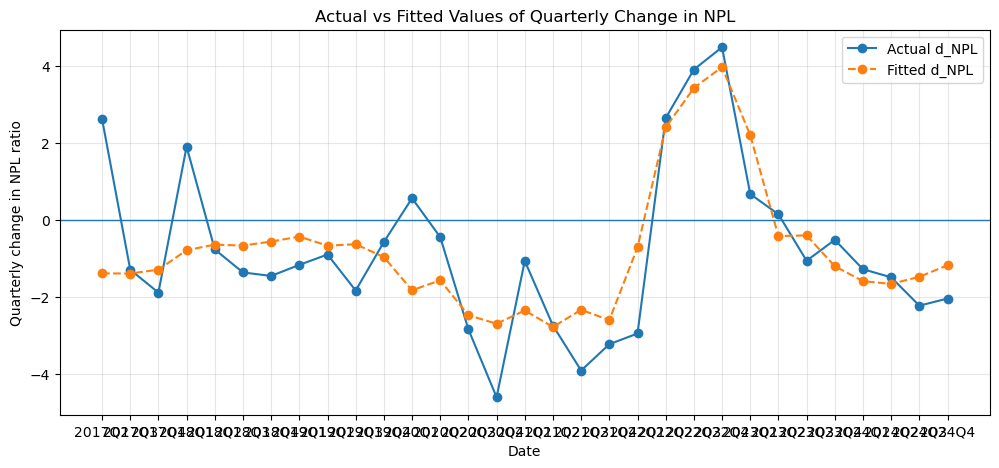

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(
    model_data["date"],
    model_data["d_NPL"],
    marker="o",
    label="Actual d_NPL"
)

plt.plot(
    model_data["date"],
    model_data["fitted"],
    marker="o",
    linestyle="--",
    label="Fitted d_NPL"
)

plt.axhline(0, linewidth=1)

plt.title("Actual vs Fitted Values of Quarterly Change in NPL")
plt.xlabel("Date")
plt.ylabel("Quarterly change in NPL ratio")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [8]:
# regression model (without war dummy)

X1 = df_fe[
    [
        "gdp_growth",
        "CPI",
        "fx_change",
        "policy_rate"
    ]
]

y1 = df_fe["d_NPL"]

model1_data = pd.concat([X1, y1], axis=1).dropna()

X1_clean = model1_data.drop(columns="d_NPL")
y1_clean = model1_data["d_NPL"]

X1_clean = sm.add_constant(X1_clean)

model1 = sm.OLS(y1_clean, X1_clean).fit()

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  d_NPL   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     10.24
Date:                Mon, 11 May 2026   Prob (F-statistic):           4.07e-05
Time:                        08:39:45   Log-Likelihood:                -52.375
No. Observations:                  31   AIC:                             114.7
Df Residuals:                      26   BIC:                             121.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -3.8952      0.721     -5.402      